In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from collections import Counter
from wordcloud import WordCloud

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
df = pd.read_csv(
    "/content/Resume.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Resume Dataset")
print(df.head())

print("\nColumn Names")
print(df.columns)

print("\nDataset Size")
print(df.shape)

Resume Dataset
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Column Names
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Dataset Size
(2484, 4)


In [7]:
df = df[["ID", "Resume_str", "Category"]]

df = df.dropna()

df = df.rename(columns={
    "Resume_str": "Resume",
    "Category": "Job_Role"
})

print("Prepared Resume Dataset")

print(df.head())

print("\nDataset Size")

print(df.shape)

Prepared Resume Dataset
         ID                                             Resume Job_Role
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...       HR
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...       HR
2  33176873           HR DIRECTOR       Summary      Over 2...       HR
3  27018550           HR SPECIALIST       Summary    Dedica...       HR
4  17812897           HR MANAGER         Skill Highlights  ...       HR

Dataset Size
(2484, 3)


In [8]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Resume"] = df["Resume"].apply(clean_text)

print(df[["Resume", "Cleaned_Resume"]].head())

                                              Resume  \
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1           HR SPECIALIST, US HR OPERATIONS      ...   
2           HR DIRECTOR       Summary      Over 2...   
3           HR SPECIALIST       Summary    Dedica...   
4           HR MANAGER         Skill Highlights  ...   

                                      Cleaned_Resume  
0  hr administratormarketing associate hr adminis...  
1  hr specialist us hr operations summary versati...  
2  hr director summary years experience recruitin...  
3  hr specialist summary dedicated driven dynamic...  
4  hr manager skill highlights hr skills hr depar...  


In [9]:
skills_list = [

    "python",
    "java",
    "sql",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "excel",
    "power bi",
    "tableau",
    "communication",
    "leadership",
    "marketing",
    "recruitment",
    "html",
    "css",
    "javascript"

]

def extract_skills(text):

    found_skills = []

    for skill in skills_list:

        if skill in text:

            found_skills.append(skill)

    return found_skills

df["Skills"] = df["Cleaned_Resume"].apply(extract_skills)

print(df[["ID", "Skills"]].head())

         ID                                       Skills
0  16852973                      [leadership, marketing]
1  22323967      [communication, marketing, recruitment]
2  33176873  [excel, leadership, marketing, recruitment]
3  27018550                       [excel, communication]
4  17812897             [excel, leadership, recruitment]


In [10]:
qualification_list = [

    "bachelor",
    "master",
    "mba",
    "btech",
    "mtech",
    "bca",
    "mca",
    "phd",
    "degree"

]

def extract_qualifications(text):

    qualifications = []

    for qualification in qualification_list:

        if qualification in text:

            qualifications.append(qualification)

    return qualifications

df["Qualifications"] = df["Cleaned_Resume"].apply(extract_qualifications)

print(df[["ID", "Qualifications"]].head())

         ID                   Qualifications
0  16852973                               []
1  22323967               [bachelor, master]
2  33176873  [bachelor, master, mba, degree]
3  27018550                               []
4  17812897                       [bachelor]


In [11]:
job_description = """

Looking for a Data Scientist with Python, SQL,
machine learning, deep learning, TensorFlow,
data analysis and communication skills.

"""

In [12]:
documents = df["Cleaned_Resume"].tolist()

documents.append(clean_text(job_description))

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [13]:
job_vector = tfidf_matrix[-1]

resume_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
).flatten()

df["Match_Score"] = similarity_scores * 100

print(df[["ID", "Job_Role", "Match_Score"]].head())

         ID Job_Role  Match_Score
0  16852973       HR     1.529449
1  22323967       HR     0.971498
2  33176873       HR     0.100110
3  27018550       HR     0.604924
4  17812897       HR     0.471618


In [14]:
matched_resumes = df.sort_values(
    by="Match_Score",
    ascending=False
)

print("Top Matching Resumes")

print(
    matched_resumes[
        ["ID", "Job_Role", "Skills", "Qualifications", "Match_Score"]
    ].head(10)
)

Top Matching Resumes
            ID                Job_Role  \
1762  12011623             ENGINEERING   
1218  21156767              CONSULTANT   
2153  34953092                 BANKING   
926   62994611             AGRICULTURE   
2291  12777487                    ARTS   
1339  18448085              AUTOMOBILE   
1142  30863060              CONSULTANT   
1091  24610685                   SALES   
331   18067556  INFORMATION-TECHNOLOGY   
194   18835363                DESIGNER   

                                                 Skills  \
1762  [python, sql, machine learning, excel, tableau...   
1218  [python, java, sql, machine learning, javascript]   
2153                    [python, sql, machine learning]   
926   [python, java, sql, tensorflow, excel, tableau...   
2291                                       [leadership]   
1339          [python, sql, excel, tableau, leadership]   
1142  [java, sql, excel, tableau, communication, htm...   
1091  [java, sql, excel, tableau, communicat

In [15]:
shortlist = matched_resumes.head(10)

print("Candidate Shortlist")

print("-----------------------------------")

print(
    shortlist[
        ["ID", "Job_Role", "Skills", "Qualifications", "Match_Score"]
    ]
)

Candidate Shortlist
-----------------------------------
            ID                Job_Role  \
1762  12011623             ENGINEERING   
1218  21156767              CONSULTANT   
2153  34953092                 BANKING   
926   62994611             AGRICULTURE   
2291  12777487                    ARTS   
1339  18448085              AUTOMOBILE   
1142  30863060              CONSULTANT   
1091  24610685                   SALES   
331   18067556  INFORMATION-TECHNOLOGY   
194   18835363                DESIGNER   

                                                 Skills  \
1762  [python, sql, machine learning, excel, tableau...   
1218  [python, java, sql, machine learning, javascript]   
2153                    [python, sql, machine learning]   
926   [python, java, sql, tensorflow, excel, tableau...   
2291                                       [leadership]   
1339          [python, sql, excel, tableau, leadership]   
1142  [java, sql, excel, tableau, communication, htm...   
1091  [ja

In [16]:
all_skills = []

for skills in df["Skills"]:

    all_skills.extend(skills)

skill_freq = Counter(all_skills)

print("Top 10 Common Skills")

print(skill_freq.most_common(10))

Top 10 Common Skills
[('excel', 1616), ('communication', 1505), ('leadership', 1028), ('marketing', 875), ('recruitment', 212), ('sql', 191), ('html', 158), ('java', 98), ('css', 90), ('javascript', 56)]


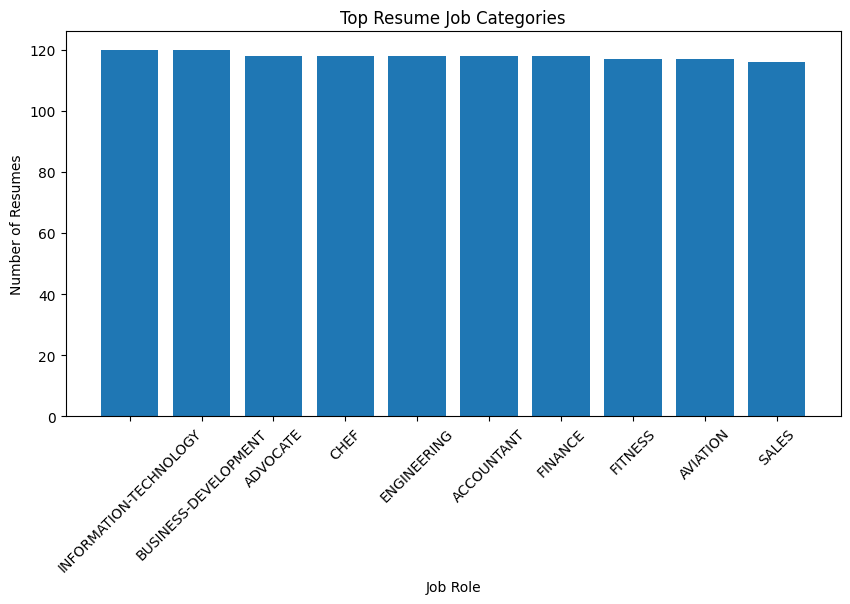

In [17]:
role_count = df["Job_Role"].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(role_count.index, role_count.values)

plt.title("Top Resume Job Categories")

plt.xlabel("Job Role")

plt.ylabel("Number of Resumes")

plt.xticks(rotation=45)

plt.show()

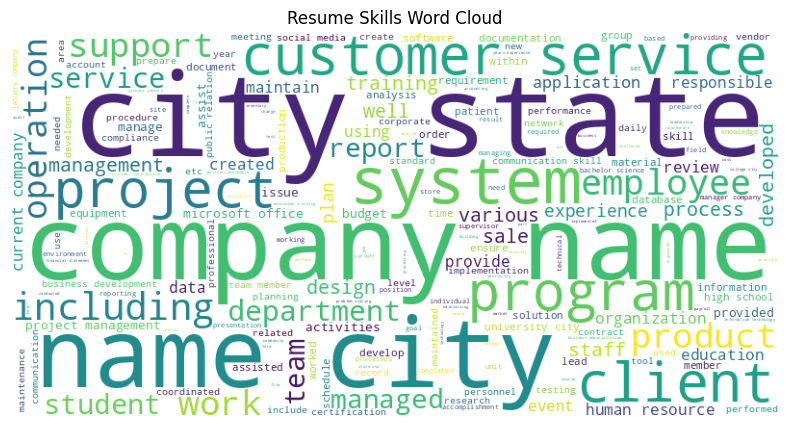

In [18]:
all_words = " ".join(df["Cleaned_Resume"])

wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Skills Word Cloud")

plt.show()

In [19]:
print("Job Resume Screening Report")

print("-----------------------------------")

print("Total Resumes :", len(df))

print("\nTop Matching Candidates")

print(
    shortlist[
        ["ID", "Job_Role", "Match_Score"]
    ]
)

print("\nTop Skills")

print(skill_freq.most_common(10))

print("\nRecommendation")

print(
    "Candidates with the highest resume-job similarity scores "
    "and relevant skills should be shortlisted for further HR review."
)

Job Resume Screening Report
-----------------------------------
Total Resumes : 2484

Top Matching Candidates
            ID                Job_Role  Match_Score
1762  12011623             ENGINEERING    19.239996
1218  21156767              CONSULTANT    18.124009
2153  34953092                 BANKING    17.228992
926   62994611             AGRICULTURE    15.592915
2291  12777487                    ARTS    15.193345
1339  18448085              AUTOMOBILE    14.496820
1142  30863060              CONSULTANT    14.225913
1091  24610685                   SALES    13.845638
331   18067556  INFORMATION-TECHNOLOGY    13.515283
194   18835363                DESIGNER    13.304763

Top Skills
[('excel', 1616), ('communication', 1505), ('leadership', 1028), ('marketing', 875), ('recruitment', 212), ('sql', 191), ('html', 158), ('java', 98), ('css', 90), ('javascript', 56)]

Recommendation
Candidates with the highest resume-job similarity scores and relevant skills should be shortlisted for furt